**This is Machine Learning project (Linear Regression), to predict the time that the delivery takes to arrive the food.**

The main framework that used in this project is "PyTorch" and there are some more important librareis in this project:
numpy, pandas, matplotlib, seaborn, sklearn, pathlib

**This is the notebook of experiences.**

In [ ]:
# Import libraries
import torch
import torch.nn as nn
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from tqdm.auto import tqdm

print(f"PyTorch version: {torch.__version__}")

Appending to ../src/main.py


In [ ]:
# Create some parameters
device = "cuda" if torch.cuda.is_available() else "cpu"
TEST = 0.2
LR = 0.005
RANDOM_SEED = 42
EPOCHS = 750

Appending to ../src/main.py


In [28]:
# Check, Clean and Prepare the data
row_data = pd.read_csv("../data/row_data.csv", na_values=['', ' ', 'N/A', 'nan', 'null'])
print(f"Data Length: {len(row_data)} | Count of Null and empty data: {row_data.isnull().sum()}")

# Clean the data
row_data = row_data.dropna()

# Turn string data into numbers
print(f"""
Print all string data: \n
{row_data["Weather"].unique()}\n
{row_data["Traffic_Level"].unique()}\n
{row_data["Time_of_Day"].unique()}\n
{row_data["Vehicle_Type"].unique()}\n
""")

row_data["Traffic_Level"] = row_data["Traffic_Level"].map({'Low': 0, "Medium": 1, 'High': 2}) # Turn "Traffic_Level" data into Nominal data
row_data = pd.get_dummies(row_data, columns=['Weather','Time_of_Day' , 'Vehicle_Type'], dtype=int) # Turn "Weather", "Time_Of_Day", "Vehicle_Type" data into one hot Encoding

# Order the data
row_data = row_data[['Order_ID', 'Distance_km', 'Traffic_Level', 'Preparation_Time_min', 'Courier_Experience_yrs',
                     'Weather_Clear', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy',
                     'Time_of_Day_Afternoon', 'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night',
                     'Vehicle_Type_Bike', 'Vehicle_Type_Car', 'Vehicle_Type_Scooter', 'Delivery_Time_min']]

row_data.to_csv("../data/data.csv", index=0) # Turn the clean data into new csvfile "data.csv"

Data Length: 1000 | Count of Null and empty data: Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

Print all string data: 

<StringArray>
['Windy', 'Clear', 'Foggy', 'Rainy', 'Snowy']
Length: 5, dtype: str

<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

<StringArray>
['Afternoon', 'Evening', 'Night', 'Morning']
Length: 4, dtype: str

<StringArray>
['Scooter', 'Bike', 'Car']
Length: 3, dtype: str




In [ ]:
# Import data.csv file and take the important data from it then turn it into numpy's array
row_data = pd.read_csv("../data/data.csv")
data = row_data.iloc[:, 1:-1].to_numpy()
labels = row_data.iloc[:, -1].to_numpy()

# Split the data into training and test data
train_data, test_data, train_label, test_label = train_test_split(
    data,
    labels,
    test_size=TEST,
    random_state=RANDOM_SEED
)

# Create standard scaler
TrainScaler = StandardScaler()
TestScaler = StandardScaler()

# Scale and Turn data into tensors
train_data = torch.tensor(TrainScaler.fit_transform(train_data), dtype=torch.float32)
test_data  = torch.tensor(TrainScaler.transform(test_data),      dtype=torch.float32)

train_label = torch.tensor(TestScaler.fit_transform(train_label.reshape(-1,1)), dtype=torch.float32)
test_label  = torch.tensor(TestScaler.transform(test_label.reshape(-1,1)),      dtype=torch.float32)

In [30]:
# Create some plot helpful functions
def pairplot(data):
    sns.pairplot(data)
    plt.show()

def plot_data(test_labels,
              Predictions=None):
    plt.style.use("dark_background")
    plt.figure(figsize=(7, 7))

    plt.scatter(test_labels, test_labels, c="g", s=4, label="Test label")

    if Predictions is not None:
        plt.scatter(Predictions, test_labels, c="r", s=4, label="Predictions")

    plt.legend(fontsize=14)
    plt.xlabel("Data")
    plt.ylabel("Label")
    plt.show()

def plot_loss(train_loss: list,
              test_loss: list,
              epochs: list):
    plt.figure(figsize=(13, 7))
    plt.style.use("dark_background")

    plt.plot(epochs, np.array(train_loss), color="orange", label="Train loss")
    plt.plot(epochs, np.array(test_loss), color="g", label="Test loss")

    plt.legend(fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()

In [ ]:
# Create the model class
class Delivery_timesModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.Linear = nn.Sequential(
            nn.Linear(16, 30),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(30, 30),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(30, 1)
        )

    def forward(self, x):
        return self.Linear(x)

# Create the model
torch.manual_seed(RANDOM_SEED)
model = Delivery_timesModel()

Writing ../src/model.py


In [ ]:
# Create loss function and optimizer
loss = nn.L1Loss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=LR)

Appending to ../src/main.py


In [ ]:
# Create the Training and Testing function
def train_test_func(model:torch.nn.Module,
                    epochs: int,
                    loss_fn: torch.nn.L1Loss,
                    optimizer: torch.optim.Optimizer):
    epochs_list = []
    train_loss_values = []
    test_loss_values = []

    for epoch in tqdm(range(epochs)):
        model.train()

        train_pred = model(train_data)
        train_loss = loss_fn(train_pred, train_label)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        model.eval() 
        with torch.inference_mode():
            test_pred = model(test_data)
            test_loss = loss_fn(test_pred, test_label)

        epochs_list.append(epoch)
        train_loss_values.append(train_loss.item())
        test_loss_values.append(test_loss.item())

        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Train loss: {train_loss} | Test loss: {test_loss.item()}", end=" \n")

    return epochs_list, train_loss_values, test_loss_values

# Train the data
epochs_list, train_loss_list, test_loss_list = train_test_func(model=model, epochs=EPOCHS, loss_fn=loss, optimizer=optimizer)

Writing ../src/train.py


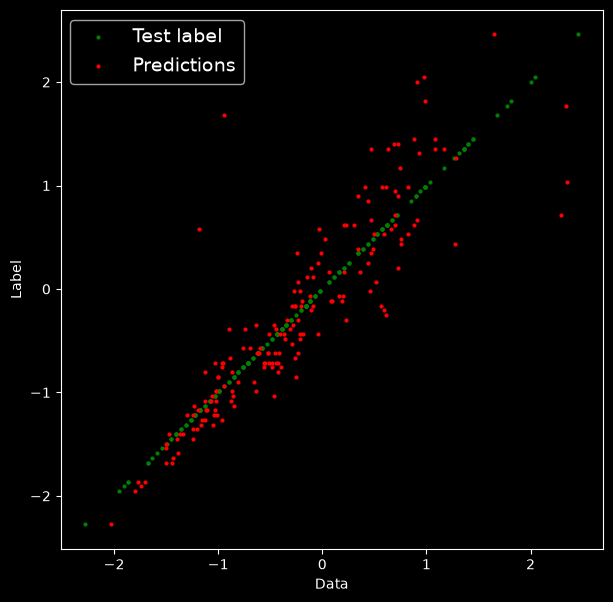

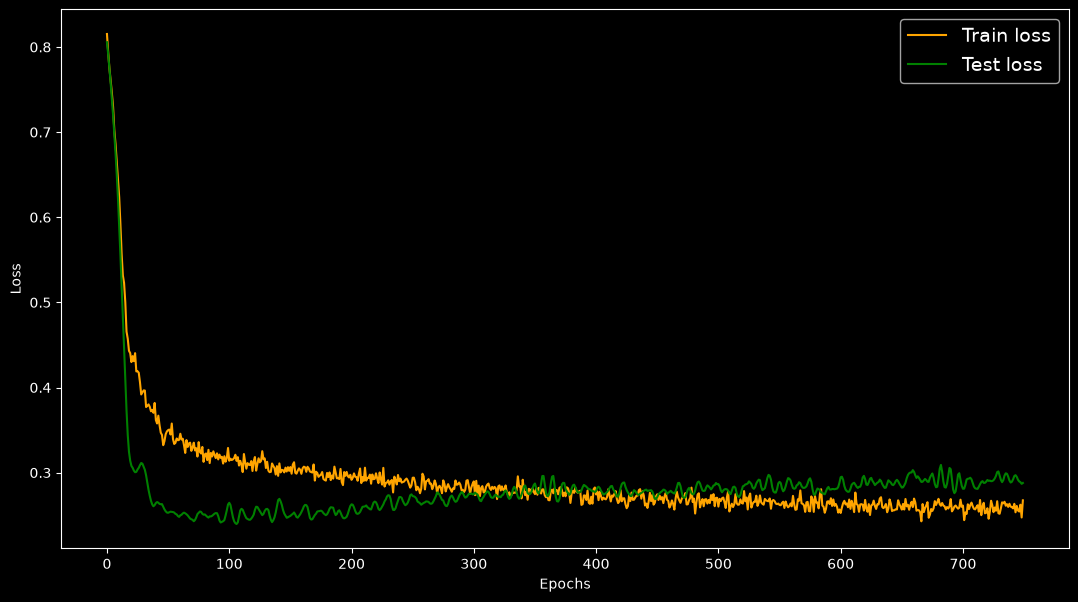

In [34]:
# Plot all needed data
plot_data(test_label, model(test_data).cpu().detach().numpy())
plot_loss(epochs=epochs_list, test_loss=test_loss_list, train_loss=train_loss_list)

In [ ]:
# Save the model
MODEL_PATH = Path("../models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "DeliveryModelV0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print("Saving the model...")
torch.save(obj=model.parameters, f=MODEL_SAVE_PATH)
print(f"The model saved successfully on: {MODEL_SAVE_PATH}")

Appending to ../src/main.py
